In [1]:
import pandas as pd # data ingestion, cleaning, and transformation
import numpy as np # linear algebra
import matplotlib.pyplot as plt # data visualization
import seaborn as sns  # advanced data visualization
import sklearn

In [2]:
df = pd.read_csv("compas-scores-two-years.csv")  # df is short form of data frame
df.head()  #gives the first 5 items in your dataset. You can, however, increase it to  any number you want. e.g. df.head(10), etc.

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [4]:
df.shape   #number of rows and columns

(7214, 53)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count            

In [6]:
df.isna().mean()*100   #you can also use df.isnull to check for missing values

# Drop columns with high missing values

id                           0.000000
name                         0.000000
first                        0.000000
last                         0.000000
compas_screening_date        0.000000
sex                          0.000000
dob                          0.000000
age                          0.000000
age_cat                      0.000000
race                         0.000000
juv_fel_count                0.000000
decile_score                 0.000000
juv_misd_count               0.000000
juv_other_count              0.000000
priors_count                 0.000000
days_b_screening_arrest      4.255614
c_jail_in                    4.255614
c_jail_out                   4.255614
c_case_number                0.304963
c_offense_date              16.065983
c_arrest_date               84.238980
c_days_from_compas           0.304963
c_charge_degree              0.000000
c_charge_desc                0.401996
is_recid                     0.000000
r_case_number               51.885223
r_charge_deg

In [7]:
df.duplicated().sum()   #to check for duplicates

np.int64(0)

In [8]:
missing_pct = df.isna().mean()*100
drop_cols = missing_pct[missing_pct >30.0]. index

In [9]:
df.drop(columns = drop_cols, inplace = True)

In [10]:
drop_cols = ["id", "name", "first", "last"]

df.drop(columns=drop_cols, inplace=True)

In [11]:
df.shape

(7214, 36)

In [12]:
drop_cols = ["compas_screening_date", "dob", "age_cat", "c_jail_in", "c_jail_out", "c_case_number", "c_offense_date"]

df.drop(columns=drop_cols, inplace=True)

In [13]:
df.shape

(7214, 29)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sex                      7214 non-null   object 
 1   age                      7214 non-null   int64  
 2   race                     7214 non-null   object 
 3   juv_fel_count            7214 non-null   int64  
 4   decile_score             7214 non-null   int64  
 5   juv_misd_count           7214 non-null   int64  
 6   juv_other_count          7214 non-null   int64  
 7   priors_count             7214 non-null   int64  
 8   days_b_screening_arrest  6907 non-null   float64
 9   c_days_from_compas       7192 non-null   float64
 10  c_charge_degree          7214 non-null   object 
 11  c_charge_desc            7185 non-null   object 
 12  is_recid                 7214 non-null   int64  
 13  is_violent_recid         7214 non-null   int64  
 14  type_of_assessment      

In [15]:
drop_cols = ["in_custody", "out_custody", "v_screening_date", "v_decile_score"]

df.drop(columns=drop_cols , inplace=True)

In [16]:
drop_cols = ["screening_date"]
df.drop(columns=drop_cols , inplace=True)

In [17]:
df.shape

(7214, 24)

In [18]:
drop_cols = ["days_b_screening_arrest"]
df.drop(columns=drop_cols , inplace=True)

In [19]:
drop_cols = ["c_days_from_compas"]
df.drop(columns=drop_cols, inplace=True)

### Descriptive Statistics

In [20]:
df.describe()

,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_recid,is_violent_recid,decile_score.1,priors_count.1,start,end,event,two_year_recid
count,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
mean,34.817993,0.067230,4.509565,0.090934,0.109371,3.472415,0.481148,0.113529,4.509565,3.472415,11.465068,553.436651,0.382867,0.450652
std,11.888922,0.473972,2.856396,0.485239,0.501586,4.882538,0.499679,0.317261,2.856396,4.882538,46.954563,399.020583,0.486120,0.497593
min,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,148.250000,0.000000,0.000000
50%,31.000000,0.000000,4.000000,0.000000,0.000000,2.000000,0.000000,0.000000,4.000000,2.000000,0.000000,530.500000,0.000000,0.000000
75%,42.000000,0.000000,7.000000,0.000000,0.000000,5.000000,1.000000,0.000000,7.000000,5.000000,1.000000,914.000000,1.000000,1.000000
max,96.000000,20.000000,10.000000,13.000000,17.000000,38.000000,1.000000,1.000000,10.000000,38.000000,937.000000,1186.000000,1.000000,1.000000


In [21]:
df.describe()

,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_recid,is_violent_recid,decile_score.1,priors_count.1,start,end,event,two_year_recid
count,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
mean,34.817993,0.067230,4.509565,0.090934,0.109371,3.472415,0.481148,0.113529,4.509565,3.472415,11.465068,553.436651,0.382867,0.450652
std,11.888922,0.473972,2.856396,0.485239,0.501586,4.882538,0.499679,0.317261,2.856396,4.882538,46.954563,399.020583,0.486120,0.497593
min,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,148.250000,0.000000,0.000000
50%,31.000000,0.000000,4.000000,0.000000,0.000000,2.000000,0.000000,0.000000,4.000000,2.000000,0.000000,530.500000,0.000000,0.000000
75%,42.000000,0.000000,7.000000,0.000000,0.000000,5.000000,1.000000,0.000000,7.000000,5.000000,1.000000,914.000000,1.000000,1.000000
max,96.000000,20.000000,10.000000,13.000000,17.000000,38.000000,1.000000,1.000000,10.000000,38.000000,937.000000,1186.000000,1.000000,1.000000


In [22]:
df.shape

(7214, 22)

In [23]:
df.isna().mean()*100  

sex                     0.000000
age                     0.000000
race                    0.000000
juv_fel_count           0.000000
decile_score            0.000000
juv_misd_count          0.000000
juv_other_count         0.000000
priors_count            0.000000
c_charge_degree         0.000000
c_charge_desc           0.401996
is_recid                0.000000
is_violent_recid        0.000000
type_of_assessment      0.000000
decile_score.1          0.000000
score_text              0.000000
v_type_of_assessment    0.000000
v_score_text            0.000000
priors_count.1          0.000000
start                   0.000000
end                     0.000000
event                   0.000000
two_year_recid          0.000000
dtype: float64

## Visualization

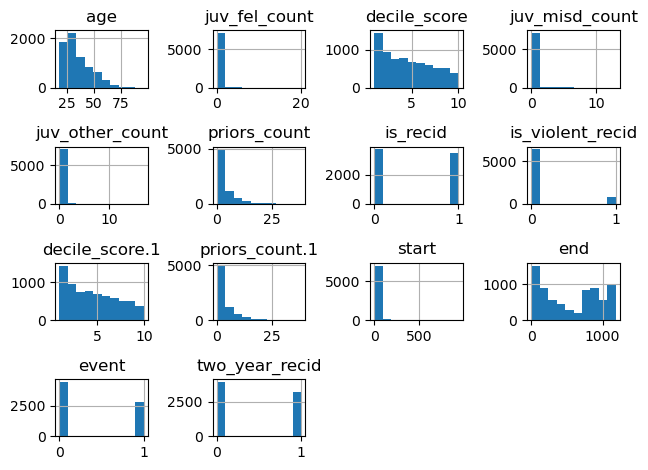

In [24]:
df.hist();
plt.tight_layout()

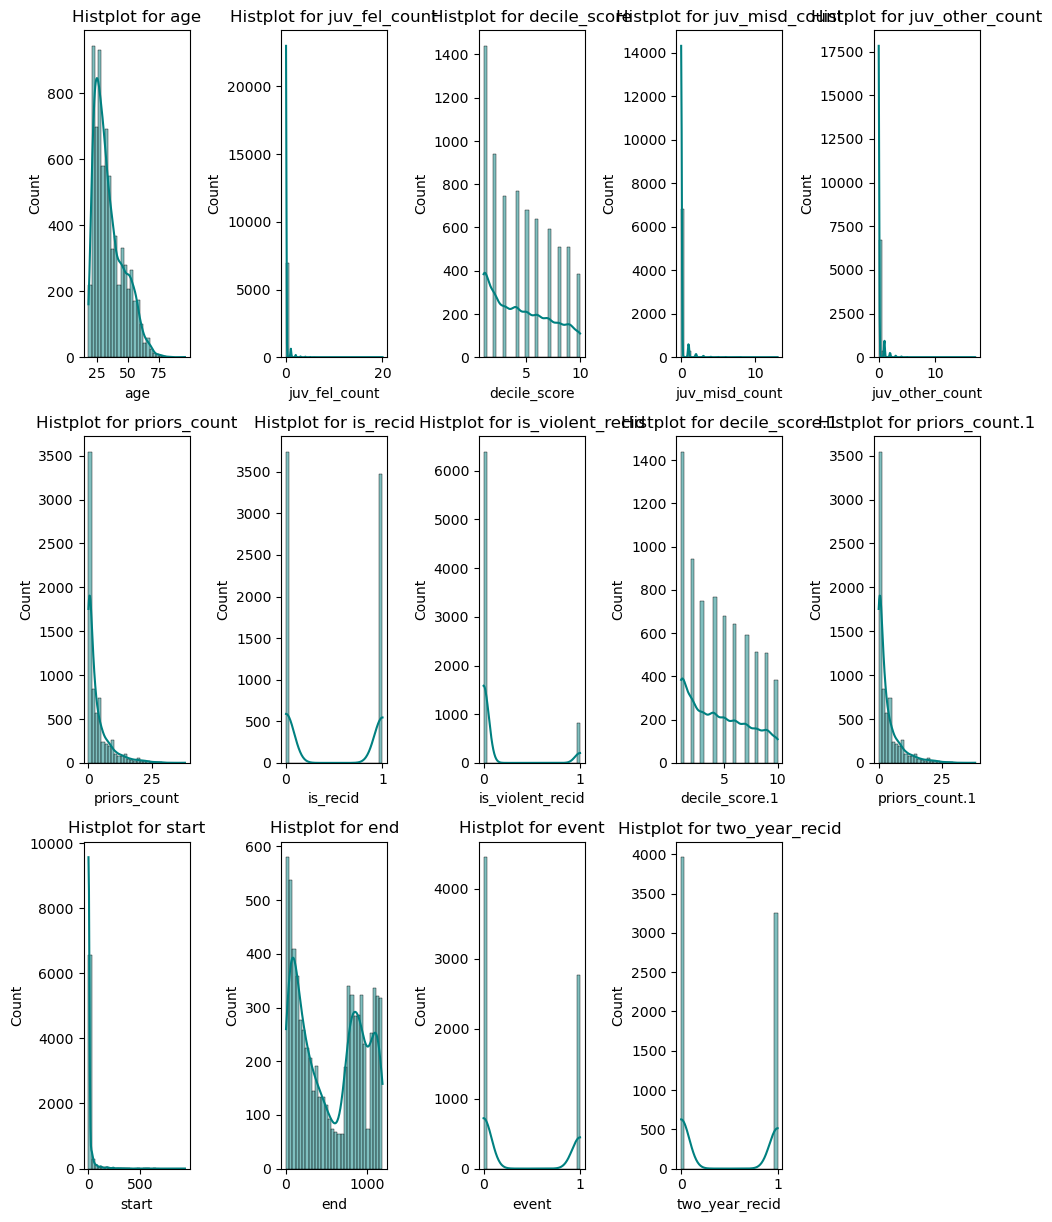

In [25]:
num_col = df.select_dtypes(include="number").columns

plt.figure(figsize=(10, 20))
for idx, col in enumerate(num_col, 1):
    plt.subplot(5, 5, idx)
    sns.histplot(df[col], bins=30, color="teal", kde=True)
    plt.title(f"Histplot for {col}")
plt.tight_layout()
plt.show()

In [26]:
#Scale
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
df[num_col] = Scaler.fit_transform(df[num_col])
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,c_charge_degree,c_charge_desc,...,type_of_assessment,decile_score.1,score_text,v_type_of_assessment,v_score_text,priors_count.1,start,end,event,two_year_recid
0,Male,2.875313,Other,-0.141855,-1.228754,-0.187414,-0.218065,-0.711240,F,Aggravated Assault w/Firearm,...,Risk of Recidivism,-1.228754,Low,Risk of Violence,Low,-0.711240,-0.244191,-0.567520,-0.787652,-0.905725
1,Male,-0.068808,African-American,-0.141855,-0.528522,-0.187414,-0.218065,-0.711240,F,Felony Battery w/Prior Convict,...,Risk of Recidivism,-0.528522,Low,Risk of Violence,Low,-0.711240,-0.052503,-0.988581,1.269597,1.104088
2,Male,-0.909985,African-American,-0.141855,-0.178407,-0.187414,1.775750,0.108063,F,Possession of Cocaine,...,Risk of Recidivism,-0.178407,Low,Risk of Violence,Low,0.108063,-0.244191,-1.229186,-0.787652,1.104088
3,Male,-0.994103,African-American,-0.141855,1.222057,1.873571,-0.218065,-0.506414,F,Possession of Cannabis,...,Risk of Recidivism,1.222057,High,Risk of Violence,Medium,-0.506414,-0.244191,1.555324,-0.787652,-0.905725
4,Male,0.688252,Other,-0.141855,-1.228754,-0.187414,-0.218065,-0.301588,F,arrest case no charge,...,Risk of Recidivism,-1.228754,Low,Risk of Violence,Low,-0.301588,-0.244191,1.374870,-0.787652,-0.905725


In [27]:
# Encode numerical data

from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_columns = ['sex', 'race', 'c_charge_degree','v_score_text', 'score_text',
                       'v_type_of_assessment', 'type_of_assessment', 'c_charge_desc']
for column_name in categorical_columns:
    le = LabelEncoder()
    df[column_name] = le.fit_transform(df[column_name])
    label_encoders[column_name] = le
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,c_charge_degree,c_charge_desc,...,type_of_assessment,decile_score.1,score_text,v_type_of_assessment,v_score_text,priors_count.1,start,end,event,two_year_recid
0,1,2.875313,5,-0.141855,-1.228754,-0.187414,-0.218065,-0.711240,0,17,...,0,-1.228754,1,0,1,-0.711240,-0.244191,-0.567520,-0.787652,-0.905725
1,1,-0.068808,0,-0.141855,-0.528522,-0.187414,-0.218065,-0.711240,0,172,...,0,-0.528522,1,0,1,-0.711240,-0.052503,-0.988581,1.269597,1.104088
2,1,-0.909985,0,-0.141855,-0.178407,-0.187414,1.775750,0.108063,0,318,...,0,-0.178407,1,0,1,0.108063,-0.244191,-1.229186,-0.787652,1.104088
3,1,-0.994103,0,-0.141855,1.222057,1.873571,-0.218065,-0.506414,0,317,...,0,1.222057,0,0,2,-0.506414,-0.244191,1.555324,-0.787652,-0.905725
4,1,0.688252,5,-0.141855,-1.228754,-0.187414,-0.218065,-0.301588,0,436,...,0,-1.228754,1,0,1,-0.301588,-0.244191,1.374870,-0.787652,-0.905725


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   7214 non-null   int64  
 1   age                   7214 non-null   float64
 2   race                  7214 non-null   int64  
 3   juv_fel_count         7214 non-null   float64
 4   decile_score          7214 non-null   float64
 5   juv_misd_count        7214 non-null   float64
 6   juv_other_count       7214 non-null   float64
 7   priors_count          7214 non-null   float64
 8   c_charge_degree       7214 non-null   int64  
 9   c_charge_desc         7214 non-null   int64  
 10  is_recid              7214 non-null   float64
 11  is_violent_recid      7214 non-null   float64
 12  type_of_assessment    7214 non-null   int64  
 13  decile_score.1        7214 non-null   float64
 14  score_text            7214 non-null   int64  
 15  v_type_of_assessment 

In [29]:
from sklearn.cluster import KMeans

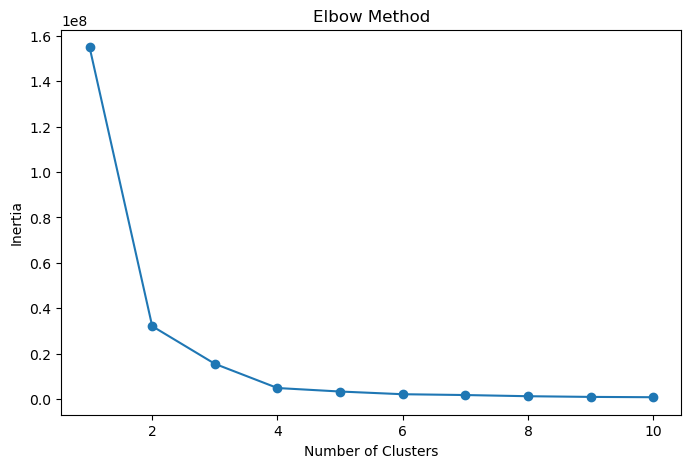

In [30]:
#Modelling Using Kmeans

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [31]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

kmeans.fit(df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [32]:
df['cluster_km']= kmeans.labels_

In [33]:
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,c_charge_degree,c_charge_desc,...,decile_score.1,score_text,v_type_of_assessment,v_score_text,priors_count.1,start,end,event,two_year_recid,cluster_km
0,1,2.875313,5,-0.141855,-1.228754,-0.187414,-0.218065,-0.711240,0,17,...,-1.228754,1,0,1,-0.711240,-0.244191,-0.567520,-0.787652,-0.905725,0
1,1,-0.068808,0,-0.141855,-0.528522,-0.187414,-0.218065,-0.711240,0,172,...,-0.528522,1,0,1,-0.711240,-0.052503,-0.988581,1.269597,1.104088,3
2,1,-0.909985,0,-0.141855,-0.178407,-0.187414,1.775750,0.108063,0,318,...,-0.178407,1,0,1,0.108063,-0.244191,-1.229186,-0.787652,1.104088,2
3,1,-0.994103,0,-0.141855,1.222057,1.873571,-0.218065,-0.506414,0,317,...,1.222057,0,0,2,-0.506414,-0.244191,1.555324,-0.787652,-0.905725,2
4,1,0.688252,5,-0.141855,-1.228754,-0.187414,-0.218065,-0.301588,0,436,...,-1.228754,1,0,1,-0.301588,-0.244191,1.374870,-0.787652,-0.905725,1


In [34]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

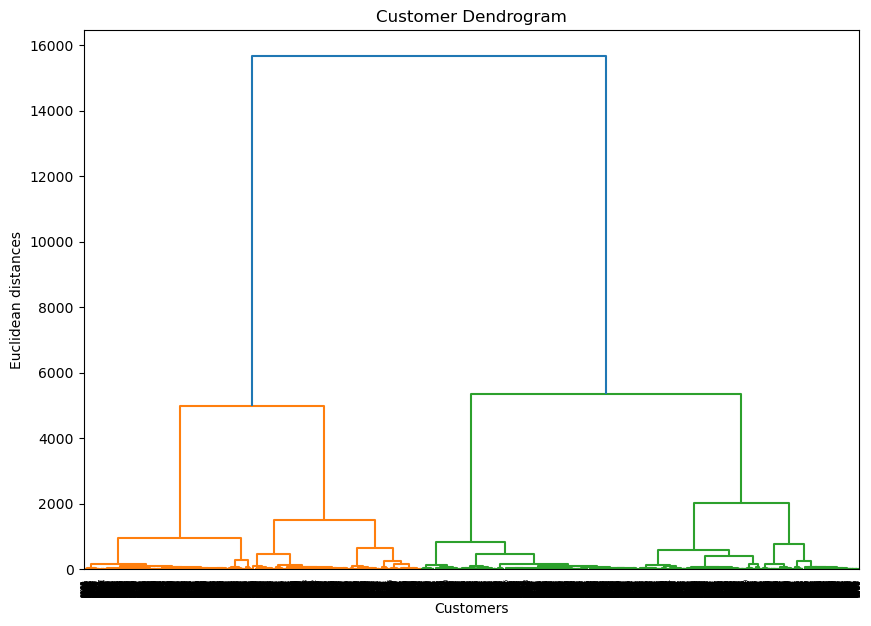

In [35]:
plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(df, method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [36]:
agg_clustering = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
agg_clustering.fit_predict(df)

# Add the cluster labels to the original DataFrame
df['cluster_km'] = agg_clustering.labels_

df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,c_charge_degree,c_charge_desc,...,decile_score.1,score_text,v_type_of_assessment,v_score_text,priors_count.1,start,end,event,two_year_recid,cluster_km
0,1,2.875313,5,-0.141855,-1.228754,-0.187414,-0.218065,-0.711240,0,17,...,-1.228754,1,0,1,-0.711240,-0.244191,-0.567520,-0.787652,-0.905725,2
1,1,-0.068808,0,-0.141855,-0.528522,-0.187414,-0.218065,-0.711240,0,172,...,-0.528522,1,0,1,-0.711240,-0.052503,-0.988581,1.269597,1.104088,0
2,1,-0.909985,0,-0.141855,-0.178407,-0.187414,1.775750,0.108063,0,318,...,-0.178407,1,0,1,0.108063,-0.244191,-1.229186,-0.787652,1.104088,1
3,1,-0.994103,0,-0.141855,1.222057,1.873571,-0.218065,-0.506414,0,317,...,1.222057,0,0,2,-0.506414,-0.244191,1.555324,-0.787652,-0.905725,1
4,1,0.688252,5,-0.141855,-1.228754,-0.187414,-0.218065,-0.301588,0,436,...,-1.228754,1,0,1,-0.301588,-0.244191,1.374870,-0.787652,-0.905725,3


In [48]:
target = "two_year_recid"

feature_cols = [
    "sex",
    "age",
    "race",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "c_charge_degree",
]

feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df[target].copy()

In [49]:
X_no_race = X.drop(columns=["race"], errors="ignore")

In [50]:
y = df["two_year_recid"].astype(float)
y = (y >= 0.5).astype(int)

print(y.unique())
print(y.value_counts())


[0 1]
two_year_recid
0    3963
1    3251
Name: count, dtype: int64


In [51]:
new_person = pd.DataFrame([{
    "sex": 1,
    "age": 28,
    "race": 2,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 1,
    "priors_count": 3,
    "c_charge_degree": 0,
}])

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

cat_cols = ["sex", "race", "c_charge_degree"]
cat_cols = [c for c in cat_cols if c in X.columns]
num_cols = [c for c in numerical_columns if c in X.columns]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

log_reg = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

log_reg.fit(X_train, y_train)
print(log_reg.predict_proba(new_person)[0, 1])

4.4110540204700665e-06


In [55]:
print("LogReg P(reoffend):", log_reg.predict_proba(new_person)[0, 1])
print("RF P(reoffend):", rf.predict_proba(new_person)[0, 1])

LogReg P(reoffend): 4.4110540204700665e-06
RF P(reoffend): 0.76


In [56]:
print(X_train.columns.tolist())
print(new_person.columns.tolist())
print(new_person)
print(X.dtypes)

['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']
['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']
   sex  age  race  juv_fel_count  juv_misd_count  juv_other_count  \
0    1   28     2              0               0                1   

   priors_count  c_charge_degree  
0             3                0  
sex                  int64
age                float64
race                 int64
juv_fel_count      float64
juv_misd_count     float64
juv_other_count    float64
priors_count       float64
c_charge_degree      int64
dtype: object


In [57]:
from sklearn.metrics import roc_auc_score, classification_report

log_p = log_reg.predict_proba(X_test)[:, 1]
rf_p = rf.predict_proba(X_test)[:, 1]

print("Base rate:", y_test.mean())
print("LogReg AUC:", roc_auc_score(y_test, log_p), "mean p:", log_p.mean())
print("RF AUC:    ", roc_auc_score(y_test, rf_p), "mean p:", rf_p.mean())
print(classification_report(y_test, (rf_p >= 0.5).astype(int)))

Base rate: 0.45045045045045046
LogReg AUC: 0.7245814336987099 mean p: 0.4899174071880029
RF AUC:     0.6666039383063342 mean p: 0.44361446587280184
              precision    recall  f1-score   support

           0       0.67      0.67      0.67       793
           1       0.60      0.59      0.59       650

    accuracy                           0.64      1443
   macro avg       0.63      0.63      0.63      1443
weighted avg       0.64      0.64      0.64      1443



In [58]:
from sklearn.calibration import CalibratedClassifierCV

rf_cal = CalibratedClassifierCV(rf, method="sigmoid", cv=3)
rf_cal.fit(X_train, y_train)
print("Calibrated RF:", rf_cal.predict_proba(new_person)[0, 1])

Calibrated RF: 0.5757130242224614
